Title: Data Visualization III 


PROBLEM STATEMENT: 
 
Download the Iris flower dataset or any other dataset into a DataFrame.(e.g., 
https://archive.ics.uci.edu/ml/datasets/Iris). Scan the dataset and give the inference as: 
1. List down the features and their types (e.g., numeric, nominal) available in the dataset. 
 
2. Create a histogram for each feature in the dataset to illustrate the feature distributions. 
 
3. Create a boxplot for each feature in the dataset. 
 
4. Compare distributions and identify outliers. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
iris = sns.load_dataset('iris')

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print("Features and their data types:\n")
print(iris.dtypes)

Features and their data types:

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


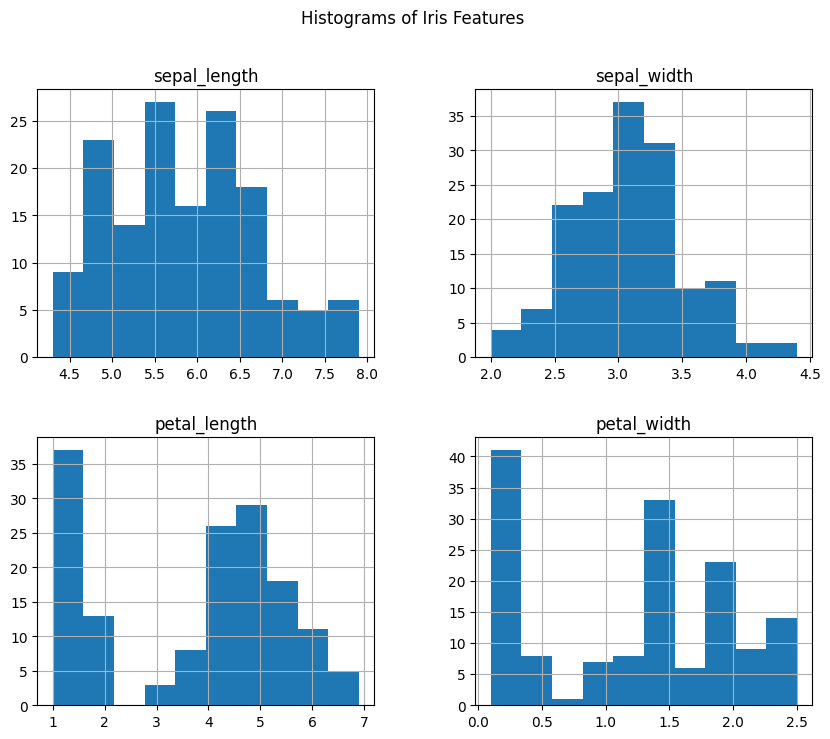

In [4]:
iris.hist(figsize=(10,8))
plt.suptitle("Histograms of Iris Features")
plt.show()

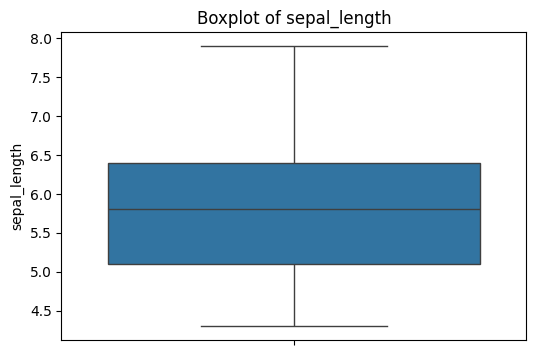

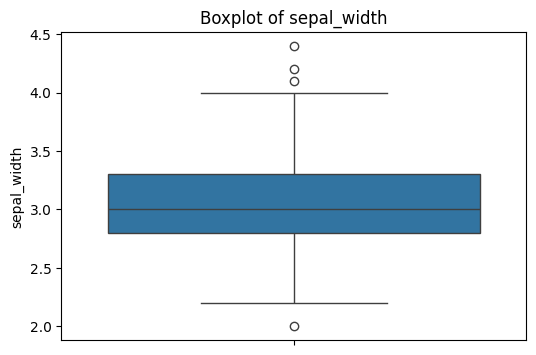

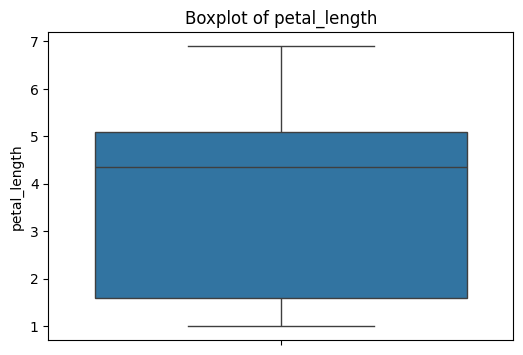

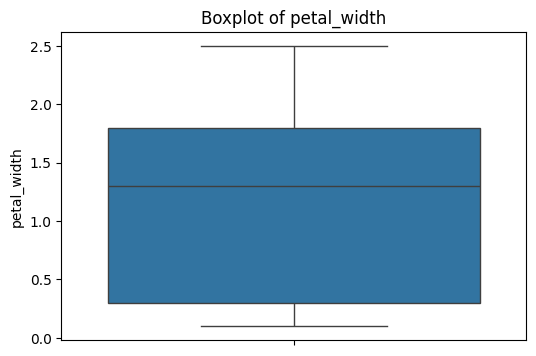

In [5]:
numeric_cols = iris.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=iris[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [6]:
for col in numeric_cols:
    Q1 = iris[col].quantile(0.25)
    Q3 = iris[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = iris[(iris[col] < lower) | (iris[col] > upper)]
    
    print(f"{col} - Number of outliers:", len(outliers))

sepal_length - Number of outliers: 0
sepal_width - Number of outliers: 4
petal_length - Number of outliers: 0
petal_width - Number of outliers: 0


In [7]:
# Summary statistics for comparison
print("Statistical Summary:\n")
print(iris.describe())

# Compare spread using standard deviation
print("\nStandard Deviation (Spread of Features):")
print(iris.std(numeric_only=True))

# Compare median values
print("\nMedian Values:")
print(iris.median(numeric_only=True))

Statistical Summary:

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Standard Deviation (Spread of Features):
sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64

Median Values:
sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64


Observation: Petal features have lower spread and better separation compared to sepal features.